In [1]:
from astroquery.gaia import Gaia
import pandas as pd
#query gaia data
query = """
SELECT TOP 100 *
FROM gaiadr3.vari_rrlyrae
WHERE pf IS NOT NULL
  AND num_clean_epochs_g > 40
ORDER BY num_clean_epochs_g DESC
"""

job = Gaia.launch_job_async(query)#asynchronous to not overload server
rrl_results = job.get_results()
df_rrl = rrl_results.to_pandas()#convert to pandas df
source_ids = df_rrl['source_id'].tolist()#get list of source ids

light_curves = {}

# I was getting an Error 500 from overloading the server, so I fixed it by creating a loop that queries 1 light curve at a time and then appends it to the pandas dataframe
for i, source_id in enumerate(source_ids):
    try:
        # distinct=True is required to get the specific light curve
        datalink = Gaia.load_data(ids=[source_id], data_release='Gaia DR3', 
                                  retrieval_type='EPOCH_PHOTOMETRY', 
                                  format='votable')
        
        # i only need the first table from the dictionary it returns
        dl_keys = list(datalink.keys())
        if len(dl_keys) > 0:
            lc_table = datalink[dl_keys[0]][0].to_table() # Convert to Astropy Table
            light_curves[source_id] = lc_table.to_pandas() # Store as Pandas
            
            if i % 10 == 0: print(f"Fetched {i+1}/100...")
            
    except Exception as e:
        print(f"Failed to fetch {source_id}: {e}")

print(f"Successfully downloaded {len(light_curves)} light curves.")

INFO: Query finished. [astroquery.utils.tap.core]
Fetched 1/100...
Fetched 11/100...
Fetched 21/100...
Fetched 31/100...
Fetched 41/100...
Fetched 51/100...
500 Error 500:
Code: -1, msg: Could not retrieve data from table dl_auxiliary_schema.join_tap_aux
Source: SQL exception: Cannot retrieve data items from 'dl_auxiliary_schema.join_tap_aux' by designation: 'designation' due to: ERROR: failed to acquire resources on one or more segments
  Detail: could not connect to server: Cannot assign requested address
	Is the server running on host "10.0.3.173" and accepting
	TCP/IP connections on port 45000?
 (seg0 10.0.3.173:45000)

Cannot process request: 'https://gea.esac.esa.int/data-server/data' (req: Reqid: anonymous-cd6c1ddb-1046-11f1-858a-1866dabc88d5, retrieval access: DIRECT, retrieval type: EPOCH_PHOTOMETRY, compression: null), for user: UwsJobOwner{id='anonymous', name='null', mail='null', authUsername='null', authGroups=[], pseudo='anonymous', session='cf270f2d-86e1-479d-8518-3aefe3

In [2]:
print(df_rrl.head(10))

          solution_id            source_id        pf      pf_error  p1_o  \
0  375316653866487565  5284173207165634048  0.675420  1.145270e-05   NaN   
1  375316653866487565  5284160459706483200  0.594031  2.560468e-06   NaN   
2  375316653866487565  5284187019781084672  0.759014  4.346572e-06   NaN   
3  375316653866487565  5284172756184089344  0.644892  2.140856e-06   NaN   
4  375316653866487565  4659724368673132416  0.570075  1.484097e-06   NaN   
5  375316653866487565  4659723200444651648  0.627345  1.157564e-05   NaN   
6  375316653866487565  5284161589266997632  0.697379  4.213670e-06   NaN   
7  375316653866487565  4659759557323962752  0.652355  6.628113e-06   NaN   
8  375316653866487565  5284173550756283008  0.532471  6.337411e-07   NaN   
9  375316653866487565  5476378315113644416  0.657836  2.026528e-06   NaN   

   p1_o_error      epoch_g  epoch_g_error     epoch_bp  epoch_bp_error  ...  \
0         NaN  1664.714726   1.619656e-05  1664.725090        0.000043  ...   
1    

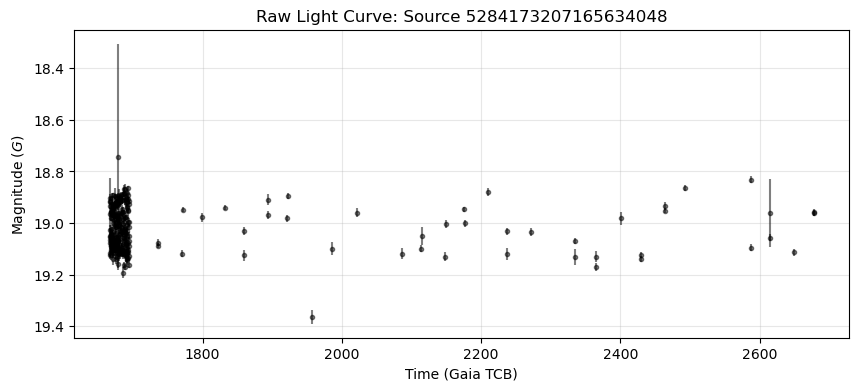

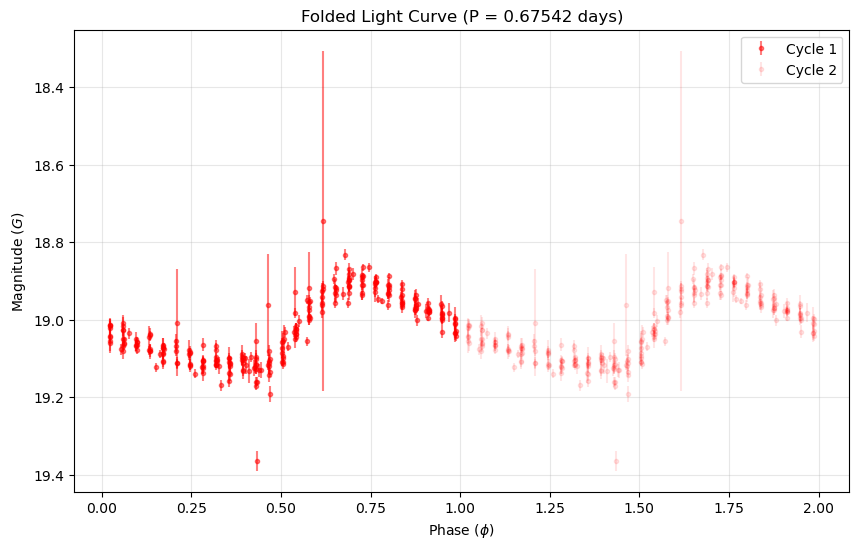

In [3]:
import matplotlib.pyplot as plt
import numpy as np

#  selecting first star from table
target_index = 0
star_row = df_rrl.iloc[target_index]
source_id = star_row['source_id']

period = star_row['pf'] #gaia period 
#i thought pf stood for pulsation frequency, but apparently its actually in units of time, so initially i calculated my period as 1/pf
# and i kept getting the wrong values, lowkey such a pain, but i figured it out so no more complaints

lc_data = light_curves[source_id] #retrieving lc

#i pulled the whole table from gaia db so now im cleaning the g_band data
g_band_data = lc_data[['g_transit_time', 'g_transit_mag', 'g_transit_flux_over_error']].dropna() 
g_band_data = g_band_data.rename(columns={
    'g_transit_time': 'time',
    'g_transit_mag': 'mag',
    'g_transit_flux_over_error': 'flux_over_error'
})

# magnitude  error derived from flux/error ratio provided by gaia 
# i took the derivative of magnitude with respect to flux to derive the 1.0857 term
# (d/dF)m= (d/dF)−2.5log10*(F)+C -> 2.5/ln(10) = 1.0857
g_band_data['error'] = 1.0857 / g_band_data['flux_over_error']

# Phase = (Time / Period) - IntegerPart(Time / Period)
g_band_data['phase'] = (g_band_data['time'] % period) / period

# --- Raw light curve plot ---
plt.figure(figsize=(10, 4))
plt.errorbar(g_band_data['time'], g_band_data['mag'], 
             yerr=g_band_data['error'], 
             fmt='.', color='black', alpha=0.5, label='G-Band')

plt.gca().invert_yaxis() # inverting y axis b/c brighter stars have lower magnitdues (thanks hipparchus/contemporary astronomers)
plt.title(f"Raw Light Curve: Source {source_id}")
plt.xlabel("Time (Gaia TCB)")
plt.ylabel("Magnitude ($G$)")
plt.grid(True, alpha=0.3)
plt.show()
# --- Phase folded plot ---
plt.figure(figsize=(10, 6))

# i plotted 2 cycles because it created a more visually appealing/digestable graph
plt.errorbar(g_band_data['phase'], g_band_data['mag'], 
             yerr=g_band_data['error'], fmt='.', color='red', alpha=0.5, label='Cycle 1')

plt.errorbar(g_band_data['phase'] + 1.0, g_band_data['mag'], 
             yerr=g_band_data['error'], fmt='.', color='red', alpha=0.1, label='Cycle 2')

plt.gca().invert_yaxis()
plt.title(f"Folded Light Curve (P = {period:.5f} days)")
plt.xlabel("Phase ($\phi$)")
plt.ylabel("Magnitude ($G$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
print(lc_data.columns)

Index(['transit_id', 'g_transit_time', 'g_transit_flux',
       'g_transit_flux_error', 'g_transit_flux_over_error', 'g_transit_mag',
       'bp_obs_time', 'bp_flux', 'bp_flux_error', 'bp_flux_over_error',
       'bp_mag', 'rp_obs_time', 'rp_flux', 'rp_flux_error',
       'rp_flux_over_error', 'rp_mag', 'variability_flag_g_reject',
       'variability_flag_bp_reject', 'variability_flag_rp_reject',
       'g_other_flags', 'bp_other_flags', 'rp_other_flags',
       'rejected_by_photometry'],
      dtype='object')


Gaia Reported Period: 0.67542 days
Lomb-Scargle Estimated Period: 0.67544 days


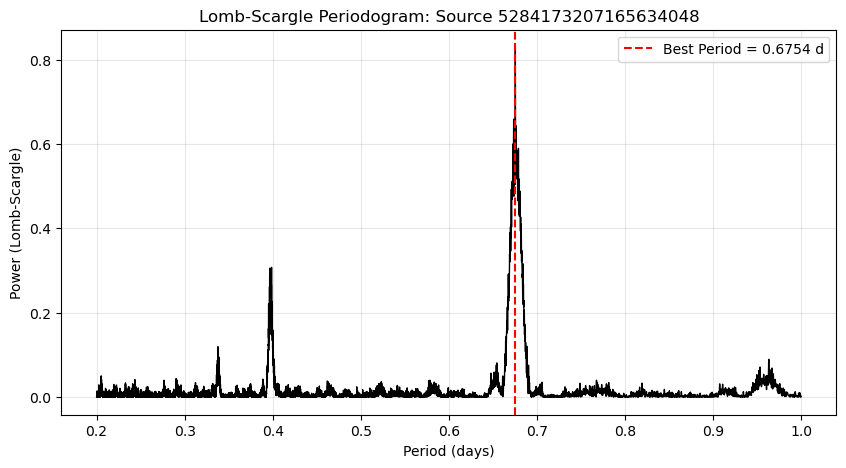

In [5]:
from astropy.timeseries import LombScargle

#Lomb Scargle Periodigrams (goofy name lol) are a method of estimating the period of an oscillating data set. 
#essentially they try to fit multiple sine waves of varying frequencies to the data set
# the sine wave that tracks the best (minimizes variance) is considered the best fit. You can then use the period of this sine wave to approximate teh period of your data!
# the periodogram is plotted w/ sin freq on x-axis and power (how good that sine wave fit to the data) on the y-axis

#frequency grid
min_freq = 1.0 / 1.0  # 1 day
max_freq = 1.0 / 0.2  # 0.2 days

# Lomb-Scargle Periodogram
# parameters are time (t) magnitude (y), and  the Error (dy) (optional)
frequency, power = LombScargle(g_band_data['time'], 
                               g_band_data['mag'], 
                               g_band_data['error']).autopower(minimum_frequency=min_freq,
                                                               maximum_frequency=max_freq)

# finding which sine wave fits the data the best
best_freq_index = np.argmax(power)
best_freq = frequency[best_freq_index]
best_period = 1.0 / best_freq

print(f"Gaia Reported Period: {period:.5f} days")
print(f"Lomb-Scargle Estimated Period: {best_period:.5f} days")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(1.0 / frequency, power, color='black', lw=1)

# Mark the best peak
plt.axvline(best_period, color='red', linestyle='--', label=f'Best Period = {best_period:.4f} d')

plt.title(f"Lomb-Scargle Periodogram: Source {source_id}")
plt.xlabel("Period (days)")
plt.ylabel("Power (Lomb-Scargle)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# 'g_band_data' contains light curve with 'mag' and 'flux_over_error'

# converting magnitude to flux in order to get an accurate calculated mean since finding the mean using magnitudes would be innacurate due to the logarithmic nature of the quantity
# m = -2.5 * log10(F)  => inverting log func. w/ exp base 10 => F = 10^(-0.4 * m)
g_band_data['flux_arbitrary'] = 10**(-0.4 * g_band_data['mag'])

#using numpy to find mean flux
mean_flux = np.mean(g_band_data['flux_arbitrary'])

# taking log of mean flux gives accurate mean magnitude
estimated_mean_mag = -2.5 * np.log10(mean_flux)

# comparing with simple mean for fun
simple_mean_mag = np.mean(g_band_data['mag'])

#comparing w/ gaia official value
gaia_mean = star_row['int_average_g']

print(f"Simple Mean:           {simple_mean_mag:.4f}")
print(f"Flux-Weighted Mean:    {estimated_mean_mag:.4f}")
print(f"Gaia Official Value:   {gaia_mean:.4f}")
print(f"Difference:            {estimated_mean_mag - gaia_mean:.4f} mag")

Simple Mean:           19.0228
Flux-Weighted Mean:    19.0194
Gaia Official Value:   19.0215
Difference:            -0.0020 mag


In [7]:
#it seems like the simple mean is closer to the gaia value? interesting

In [8]:
results_list = [] # initializing a list to store the results

print(f"Processing {len(df_rrl)} stars...")

for index, row in df_rrl.iterrows():
    source_id = row['source_id']
    
    # pulling gaia values
    gaia_period = row['pf']
    gaia_mag = row['int_average_g'] # RR Lyrae mean mag column
    
    # retrieving light curve data
    if source_id in light_curves:
        lc = light_curves[source_id]
        
        # filtering for g-band
        # added a check to make sure the column exists because i kept pulling the wrong/nonexistent data
        if 'g_transit_time' in lc.columns and 'g_transit_mag' in lc.columns:
            g_data = lc[['g_transit_time', 'g_transit_mag', 'g_transit_flux_over_error']].dropna()
            
            t = g_data['g_transit_time'].values
            y = g_data['g_transit_mag'].values
            dy = 1.0857 / g_data['g_transit_flux_over_error'].values # Approx error
            
            # finding the period w/ lomb scargle ---
            # A good search range for RR Lyrae variables is 0.2 to 1.0 days (source: https://ogle.astrouw.edu.pl/atlas/RR_Lyr.html)
            frequency, power = LombScargle(t, y, dy).autopower(minimum_frequency=1.0, 
                                                               maximum_frequency=5.0)
            best_freq = frequency[np.argmax(power)]
            my_period = 1.0 / best_freq
            
            # --- calculating mean magnitude w. weighted flux
            flux_arbitrary = 10**(-0.4 * y)
            mean_flux = np.mean(flux_arbitrary)
            my_mag = -2.5 * np.log10(mean_flux)
            
            # Store everything
            results_list.append({
                'source_id': source_id,
                'gaia_period': gaia_period,
                'my_period': my_period,
                'gaia_mag': gaia_mag,
                'my_mag': my_mag
            })

# Convert to DataFrame for easy plotting
results_df = pd.DataFrame(results_list)
print(f"Done! Analyzed {len(results_df)} stars.")

Processing 100 stars...
Done! Analyzed 98 stars.


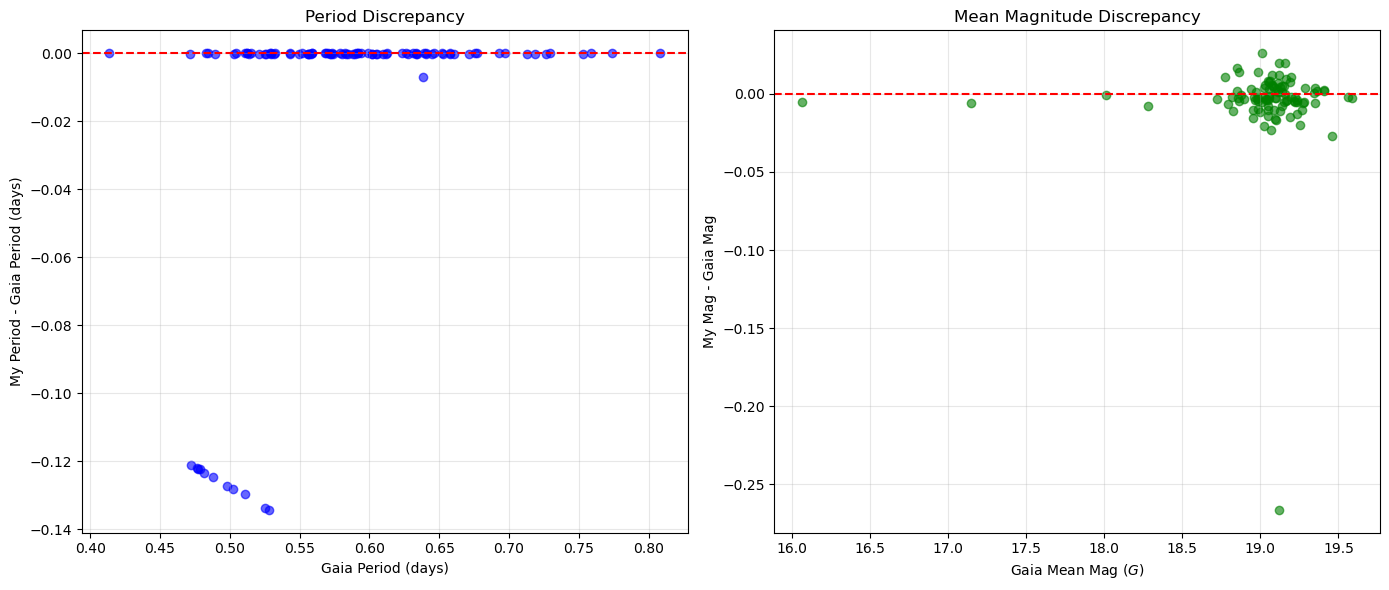

Mean Period Difference: -0.014242 days
Mean Magnitude Difference: -0.0043 mag


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# period comparison plot
# plot the Difference (My Period - Gaia Period) vs Gaia Period
period_diff = results_df['my_period'] - results_df['gaia_period']

ax[0].scatter(results_df['gaia_period'], period_diff, color='blue', alpha=0.6)
ax[0].axhline(0, color='red', linestyle='--') # The "Perfect Match" line
ax[0].set_title('Period Discrepancy')
ax[0].set_xlabel('Gaia Period (days)')
ax[0].set_ylabel('My Period - Gaia Period (days)')
ax[0].grid(True, alpha=0.3)

# magnitude comparison
# plotting (My Mag - Gaia Mag) vs Gaia Mag
mag_diff = results_df['my_mag'] - results_df['gaia_mag']

ax[1].scatter(results_df['gaia_mag'], mag_diff, color='green', alpha=0.6)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('Mean Magnitude Discrepancy')
ax[1].set_xlabel('Gaia Mean Mag ($G$)')
ax[1].set_ylabel('My Mag - Gaia Mag')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print stats for report
print(f"Mean Period Difference: {np.mean(period_diff):.6f} days")
print(f"Mean Magnitude Difference: {np.mean(mag_diff):.4f} mag")

### Some Comments on the Data

   * __Period:__
     The period is matched very well, with the exception of the strip of stars that do not adhere to the fit, with a period of ~ 0.5 days. Over an interval of ~.1 days the Gaia data is off by a margin of ~.125 days. I have two theories for why my data includes the divergent strip.
        * Hypothesis 1: [The OGLE Atlas of Variable Star Light Curves](https://ogle.astrouw.edu.pl/atlas/RR_Lyr.html) has a very educational page that details the different types of RR Lyrae stars and how they behave. The website discusses the Blazhko effect. The Blazhko effect describes a curious characteristic of RR Lyrae stars; their period and amplitude change periodically! So over the course of one cycle, you will see a variable star shorten its period, and increase its brightness, and then return to normal. This could account for why some of the stars are deviating from the best fit period.
    
        * Hypothesis 2: This is the theory that I believe to be more likely. The source cited above describes that there are multiple "pulsation modes" for RR Lyrae stars. The primary mode RRab stars) occurs on a period of 0.2 to 1.0 days, however there is a second mode, for stars (called RRc stars) with periods between 0.2 and 0.5 days. If Gaia happened to accidentally catalog some RRc stars as RRab stars, then it would explain the trend seen very well, especially since their period is within the bounds observed for RRc stars. Not to mention the linear trend insinuates that there is a related nature to the divergence of these stars from the main strip; such as having a consistent period that oscillates due to a different mechanism than RRab stars.

   * __Magnitude:__
        The magnitude is matched well with a clear standard deviation for the matching of the data sets. My theory as to why the magnitude may diverge is because of the Blazhko effect described earlier. Since the stars' magnitude varies periodically, but the period in which it varies periodically, it is possible that the data for these stars deviates from whatever the current calculated mean is, yet they still deviate with a consistent manner due to the undulating nature of the phenomena.

### Fourier Analysis

Since the period of the stars is known, approximating the stars fluxes with some function f(t) can be done with a fourier series. 

    f(t) = A_0 + SUM[a_n * cos(nwt) + b_n * sin(nwt)]

This can be reduced to a linear system of equations since w is a known quantity (found w/ the periodogram). 

y = X B

Y is a column vector consisting of the observed fluxes. X is a matrix that consists of the known terms in the fourier series (1, cos(nwt_initial), sin(wt_initial)). B is a column vector consisting of the unknown coefficients A_0, a_n, and b_n. 

This system of equations allows us to solve for B pretty easily (with a computer, haha). Multiplying both sides by X_transpose makes it so B is forming an inner product with a square matrix. Since (X_transpose X) is a square matrix it is also invertible. 

Therefore B (and all the coefficients to the series) is given by : B = (X_transpose X)^-1 X_transpose y

Luckily numpy has functions to do this for me!!!

In [10]:
import numpy as np

def create_design_matrix(t, period, K):
    """
    Parameters:
    - t: Array of observation times
    - period: The period of the star 
    - K: The iteration of the series summation
    
    Returns X; the design matrix with shape (N, 2K+1)
    """
    # calculate w
    omega = 2 * np.pi / period
    
    # creating X matrix
    # column of 1's to leave A_0 unchanged
    # 2 columns (sin, cos) for each K
    n_rows = len(t)
    n_cols = 1 + 2 * K
    X = np.ones((n_rows, n_cols))
    
    # Fill the columns
    for k in range(1, K + 1):
        # k=1 -> cols 1,2; k=2 -> cols 3,4; etc.
        sin_col = 2 * k - 1
        cos_col = 2 * k
        
        X[:, sin_col] = np.sin(k * omega * t)
        X[:, cos_col] = np.cos(k * omega * t)
        
    return X



### Function usage:
 1. Get data for the specific star
  ex: Star ID: 4659713442253931776 (star for the next part)

 target_id = 4659713442253931776
 lc = light_curves[target_id] 
 t_obs = ...
 m_obs = ...
 period = ... (from Gaia or Lomb-Scargle)

 2. Solve for Beta (Example for K=3)
 K = 3
 X = create_design_matrix(t_obs, period, K)
 beta, residuals, rank, s = np.linalg.lstsq(X, m_obs, rcond=None)

 3. Predict the Model
 model_mags = X @ beta

In [11]:
from astroquery.gaia import Gaia

# target ID for the star to analyze 
target_id = 4659713442253931776 #star specified in the assgn.

# check to see if its already downloaded
if target_id in light_curves:
    print(f"Star {target_id} is already in your library!")
    lc_target = light_curves[target_id]
else:
    print(f"Downloading data for target star {target_id}...")
    # Fetch the light curve
    datalink = Gaia.load_data(ids=[target_id], data_release='Gaia DR3', 
                              retrieval_type='EPOCH_PHOTOMETRY', 
                              format='votable')
    
    # Extract the table 
    for key in datalink.keys():
        table = datalink[key][0].to_table().to_pandas()
        if 'mag' in table.columns or 'g_transit_mag' in table.columns: # iterate to find the table with 'mag' columns
            lc_target = table
            break
            
# clean & prep data (g-band)
if 'g_transit_mag' in lc_target.columns:
    # Wide format
    g_data = lc_target[['g_transit_time', 'g_transit_mag', 'g_transit_flux_over_error']].dropna()
    g_data.columns = ['time', 'mag', 'flux_over_error']
else:
    # Long format
    g_data = lc_target[lc_target['band'] == 'G'][['time', 'mag', 'flux_over_error']].dropna()

# Get the period from 'vari_rrlyrae' column pf
query = f"SELECT pf FROM gaiadr3.vari_rrlyrae WHERE source_id = {target_id}"
job = Gaia.launch_job(query)
res = job.get_results()
period = res['pf'][0]

# Calculate Phase
g_data['phase'] = (g_data['time'] % period) / period

print(f"Ready to fit Star {target_id} (P = {period:.5f} d)")

Star 4659713442253931776 is already in your library!
Ready to fit Star 4659713442253931776 (P = 0.60501 d)


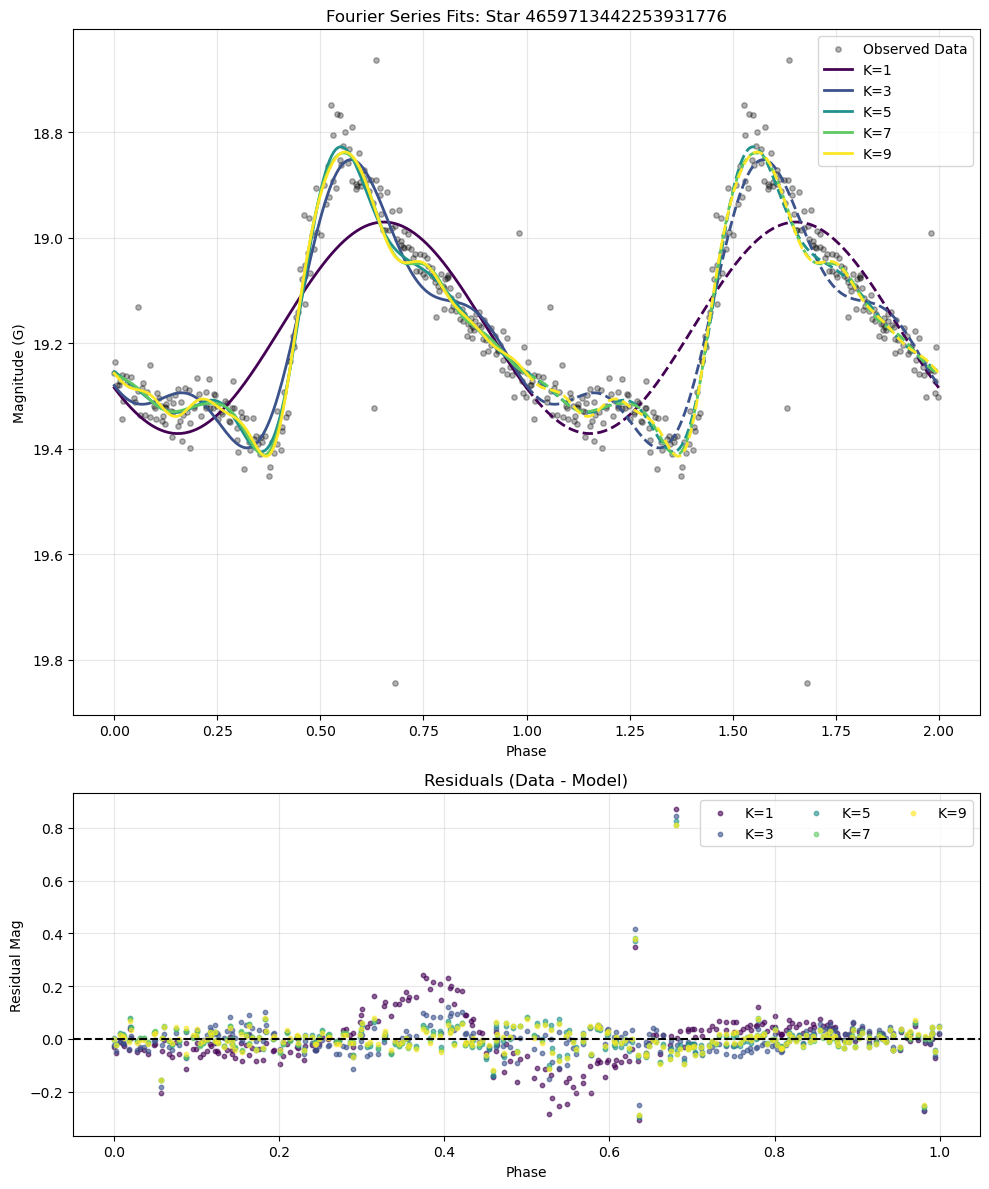

In [12]:
# prepare plotting

K_values = [1, 3, 5, 7, 9]
colors = plt.cm.viridis(np.linspace(0, 1, len(K_values)))

fig, axes = plt.subplots(2, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [2, 1]})
ax_fit = axes[0]
ax_res = axes[1]

# plotting phase folded raw data
ax_fit.scatter(g_data['phase'], g_data['mag'], color='black', alpha=0.3, s=15, label='Observed Data')
ax_fit.scatter(g_data['phase']+1, g_data['mag'], color='black', alpha=0.3, s=15) #adding a second phase just to better see the trend

# Loop through K values
for K, color in zip(K_values, colors):
    
    # Build Matrix X for Observed Time Points
    X_obs = create_design_matrix(g_data['time'].values, period, K)
    
    # Solving the y = X * beta system of eqn using least squares
    # rcond=None handles singularity warnings
    beta, residuals, rank, s = np.linalg.lstsq(X_obs, g_data['mag'].values, rcond=None)
    
    # Create smooth model for plotting
    # Generate a grid of phases 0 to 1
    phase_grid = np.linspace(0, 1, 200)
    time_grid = phase_grid * period # Convert phase back to time units for the function
    
    X_grid = create_design_matrix(time_grid, period, K)
    mag_model = X_grid @ beta # Matrix Multiplication
    
    # Plot
    ax_fit.plot(phase_grid, mag_model, color=color, lw=2, label=f'K={K}')
    ax_fit.plot(phase_grid+1, mag_model, color=color, lw=2, linestyle='--') # Plot copy
    
    # Calculate and plot residuals (Data - Model)
    # the residuals are found using what the model predicted exactly AT the observation times
    model_at_obs = X_obs @ beta
    resid = g_data['mag'] - model_at_obs
    ax_res.scatter(g_data['phase'], resid, color=color, s=10, alpha=0.6, label=f'K={K}')

# formatting
ax_fit.invert_yaxis()
ax_fit.set_title(f'Fourier Series Fits: Star {target_id}')
ax_fit.set_ylabel('Magnitude (G)')
ax_fit.set_xlabel('Phase')
ax_fit.legend()
ax_fit.grid(True, alpha=0.3)

ax_res.axhline(0, color='black', linestyle='--')
ax_res.set_title('Residuals (Data - Model)')
ax_res.set_ylabel('Residual Mag')
ax_res.set_xlabel('Phase')
ax_res.legend(ncol=3) 
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Plotting residuals is a really interesting way to visualize the efficacy of a fit. I have only worked with Fourier series in Math/Physics classes before. As a result we really only work with idealized examples and can take limits to infinity to get perfect approximations. When working with real data, there is noise in the instruments, so adding too many terms to your series can actually give a worse fit! This is because the function with try to adjust itself to pass through points that are outliers/noise, making it inaccurate for the data that is actually reliable. I had never thought about this before. The residual plot helped me determine the efficacy of my fit, however I tried overfitting some data just out of curiousity, and it seemed like plotting the residuals for overfitted data actually revealed a more "idealized" relationship. It's fascinating! I guess there is probably a sweet spot for terms depending on how much variance/noise is in your data set. In fact, maybe you want your residual plot to have some texture, otherwise it could be an indication that you've overfit your data.

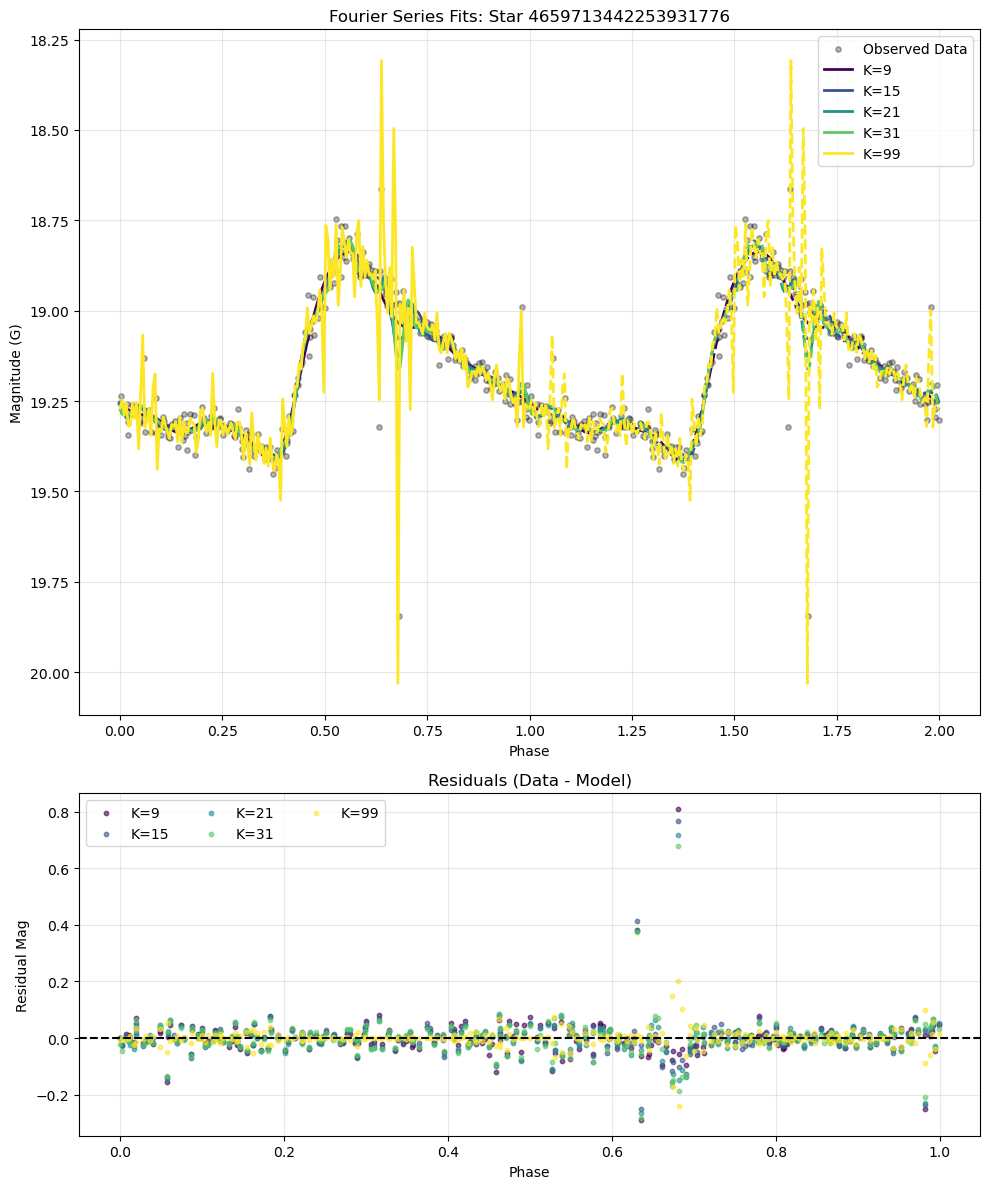

In [13]:
# Plotting other K values just for fun

K_values = [9, 15, 21, 31 , 99]
colors = plt.cm.viridis(np.linspace(0, 1, len(K_values)))

fig, axes = plt.subplots(2, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [2, 1]})
ax_fit = axes[0]
ax_res = axes[1]

# plotting phase folded raw data
ax_fit.scatter(g_data['phase'], g_data['mag'], color='black', alpha=0.3, s=15, label='Observed Data')
ax_fit.scatter(g_data['phase']+1, g_data['mag'], color='black', alpha=0.3, s=15) #adding a second phase just to better see the trend

# Loop through K values
for K, color in zip(K_values, colors):
    
    # Build Matrix X for Observed Time Points
    X_obs = create_design_matrix(g_data['time'].values, period, K)
    
    # Solving the y = X * beta system of eqn using least squares
    # rcond=None handles singularity warnings
    beta, residuals, rank, s = np.linalg.lstsq(X_obs, g_data['mag'].values, rcond=None)
    
    # Create smooth model for plotting
    # Generate a grid of phases 0 to 1
    phase_grid = np.linspace(0, 1, 200)
    time_grid = phase_grid * period # Convert phase back to time units for the function
    
    X_grid = create_design_matrix(time_grid, period, K)
    mag_model = X_grid @ beta # Matrix Multiplication
    
    # Plot
    ax_fit.plot(phase_grid, mag_model, color=color, lw=2, label=f'K={K}')
    ax_fit.plot(phase_grid+1, mag_model, color=color, lw=2, linestyle='--') # Plot copy
    
    # Calculate and plot residuals (Data - Model)
    # the residuals are found using what the model predicted exactly AT the observation times
    model_at_obs = X_obs @ beta
    resid = g_data['mag'] - model_at_obs
    ax_res.scatter(g_data['phase'], resid, color=color, s=10, alpha=0.6, label=f'K={K}')

# formatting
ax_fit.invert_yaxis()
ax_fit.set_title(f'Fourier Series Fits: Star {target_id}')
ax_fit.set_ylabel('Magnitude (G)')
ax_fit.set_xlabel('Phase')
ax_fit.legend()
ax_fit.grid(True, alpha=0.3)

ax_res.axhline(0, color='black', linestyle='--')
ax_res.set_title('Residuals (Data - Model)')
ax_res.set_ylabel('Residual Mag')
ax_res.set_xlabel('Phase')
ax_res.legend(ncol=3) 
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Now that I'm reading part 7, I'm laughing at my previous markdown cell. Of course someone has figured out how to find the sweet spot. I can't wait to learn how, lets get after it lol

I realized that noise is not isotropically spread throughout the data set, since in astronomy there are many unpredictable circumstances that increase error at certain moments in time. Some examples would be:

photon noise: Fainter observations (when the star is at minimum brightness) have fewer photons, so the statistical noise (sqrt(N)) is higher relative to the signal.

Instrument Conditions: Some data might be taken during bad weather, high background light, or when the satellite is jittering As a result a cross-validation model that doesn't account for error when finding a fit may not be as good as one that does. 

I am comparing two cross validation models:

#1 does not account for data set error bounds. It splits the data 70/30 and loops through K = 1 through 25 then uses Root mean squared to track the error. The K number with the lowest RMS is considered the best fit.

#2 accounts for data set error bounds. I used Chi-Squared which removes weight from data with high error bounds. Chi-Squared divides each data point by its respective error before calculating residuals, squaring, and then summing. A data point with higher error, gets divided by a larger quantity, making it less important to the data set.

Running Cross-Validation on Star 4659713442253931776...


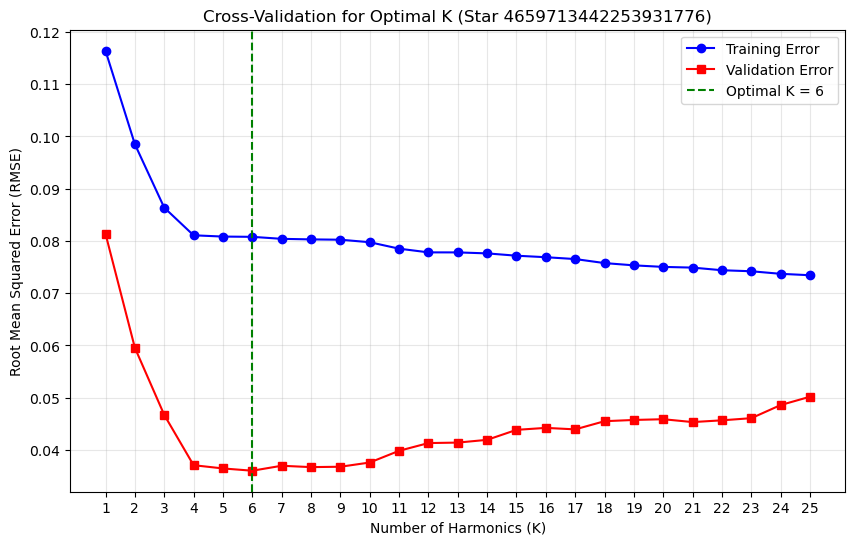

The optimal number of terms is K = 6


In [14]:
#Method 1

import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Data Shuffling
# We randomize the order so the "hidden" points are scattered randomly
np.random.seed(79) # Fixed seed for reproducibility
indices = np.arange(len(g_data))
np.random.shuffle(indices)

# Split: 70% Training, 30% Validation
split_point = int(0.7 * len(g_data))
train_idx = indices[:split_point]
valid_idx = indices[split_point:]

t_train = g_data['time'].values[train_idx]
y_train = g_data['mag'].values[train_idx]

t_valid = g_data['time'].values[valid_idx]
y_valid = g_data['mag'].values[valid_idx]

# 2. Loop through K values
K_max = 25
train_errors = []
valid_errors = []
k_list = range(1, K_max + 1)

print(f"Running Cross-Validation on Star {target_id}...")

for K in k_list:
    # A. TRAIN the model on the Training Set
    X_train = create_design_matrix(t_train, period, K)
    beta, _, _, _ = np.linalg.lstsq(X_train, y_train, rcond=None)
    
    # B. CALCULATE ERROR on Training Set (RMSE)
    # RMSE = Root Mean Squared Error
    y_pred_train = X_train @ beta
    rmse_train = np.sqrt(np.mean((y_train - y_pred_train)**2))
    train_errors.append(rmse_train)
    
    # C. TEST the model on the Validation Set (The "Truth" Test)
    # We use the beta from step A, but the X matrix from validation times
    X_valid = create_design_matrix(t_valid, period, K)
    y_pred_valid = X_valid @ beta
    
    rmse_valid = np.sqrt(np.mean((y_valid - y_pred_valid)**2))
    valid_errors.append(rmse_valid)

# 3. Plot the Results
plt.figure(figsize=(10, 6))

plt.plot(k_list, train_errors, 'o-', color='blue', label='Training Error')
plt.plot(k_list, valid_errors, 's-', color='red', label='Validation Error')

# Find the best K (Minimum Validation Error)
best_k_idx = np.argmin(valid_errors)
best_k = k_list[best_k_idx]

plt.axvline(best_k, color='green', linestyle='--', label=f'Optimal K = {best_k}')

plt.title(f"Cross-Validation for Optimal K (Star {target_id})")
plt.xlabel("Number of Harmonics (K)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_list)
plt.show()

print(f"The optimal number of terms is K = {best_k}")

Running Weighted Cross-Validation...


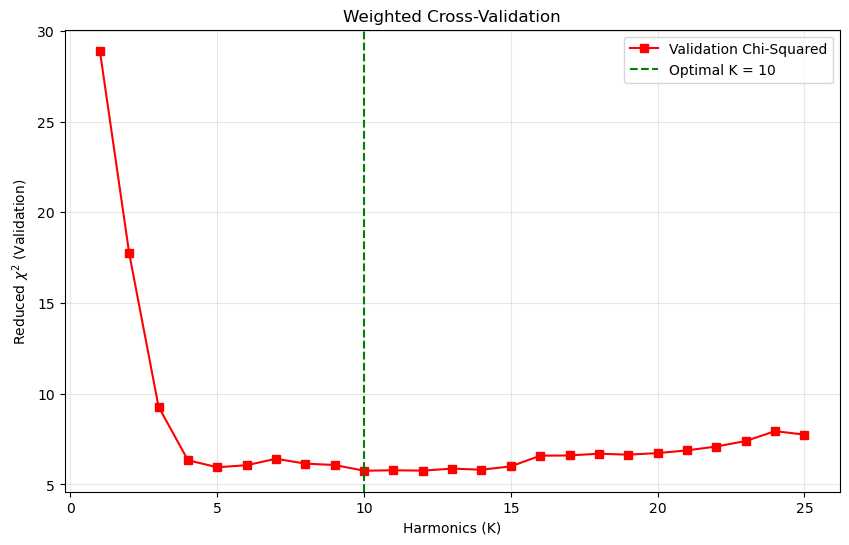

Optimal K taking noise into account: 10


In [15]:
# Method #2
# getting the error from gaia dataset
if 'error' not in g_data.columns:
    g_data['error'] = 1.0857 / g_data['flux_over_error'] #the error calculation from gaia, calculates it if i cant find it in the table.

# Shuffle time, magnitude, and error to ensure randomized model
indices = np.arange(len(g_data))
np.random.seed(569)
np.random.shuffle(indices)

split = int(0.7 * len(g_data))
train_idx, valid_idx = indices[:split], indices[split:]

t_train, y_train, dy_train = g_data['time'].values[train_idx], g_data['mag'].values[train_idx], g_data['error'].values[train_idx]
t_valid, y_valid, dy_valid = g_data['time'].values[valid_idx], g_data['mag'].values[valid_idx], g_data['error'].values[valid_idx]

# Loop through K using chi squared
K_max = 25
weighted_valid_errors = []

print(f"Running Weighted Cross-Validation...")

for K in range(1, K_max + 1):
    # Create Design Matrix
    X_train = create_design_matrix(t_train, period, K)

    # We divide X and y by the error to make it a weighted least squares assesment
    weights_train = 1.0 / dy_train
    
    # Broadcasting weights across the matrix columns
    X_train_w = X_train * weights_train[:, np.newaxis] 
    y_train_w = y_train * weights_train
    
    # Solve Weighted System
    beta, _, _, _ = np.linalg.lstsq(X_train_w, y_train_w, rcond=None)
    
    # Using Weighted Error / Chi-Squared on the cross-validation data set
    X_valid = create_design_matrix(t_valid, period, K)
    y_pred = X_valid @ beta
    
    # Calculate Chi-Squared on Validation Set
    # (Observed - Model) / Error
    chi_sq = np.sum(((y_valid - y_pred) / dy_valid)**2)
    
    # Normalize by number of points (Reduced Chi-Squared proxy)
    weighted_valid_errors.append(chi_sq / len(y_valid))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, K_max+1), weighted_valid_errors, 's-', color='red', label='Validation Chi-Squared')
best_k = np.argmin(weighted_valid_errors) + 1

plt.axvline(best_k, color='green', linestyle='--', label=f'Optimal K = {best_k}')
plt.xlabel("Harmonics (K)")
plt.ylabel("Reduced $\chi^2$ (Validation)")
plt.title("Weighted Cross-Validation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal K taking noise into account: {best_k}")

It is interesting to note that changing the seed gives me different values for the optimal K. I'm assuming that since the error is not evenly distributed throughout the data set, some data points with really high error may get tossed into the training set, while for other seeds data points with low error get tossed into the training set. This distribution then changes how well the trained model fits to the cross validation set, giving a different optimal K value. 

That said, it seems like after a K-value of 4 and before a K value of 20 the chi squared is about the same for all the fits. So I don't think one K is much better than the other, and the shuffle is affecting it in a super drastic amount.

### K folding

The changing value of K made me curious. I did research to see if there are other methods of finding the best K-value. I came across a method called K-folding. Here's how K-folding works: 

You bin your data into multiple, evenly distributed bins, so for example lets say you had 100 data points, you could make 5 bins of 20 data points. This reduces the likelihood of getting a data set with a ton of error in it. 
Next, you iterate through your K values, trying each one on all of the bins. You calculate the error that a K value has on each bin, and then average out the error. The K value that has the lowest average error across all bins is then considered the best K-value. 

Running 5-Fold Cross-Validation...


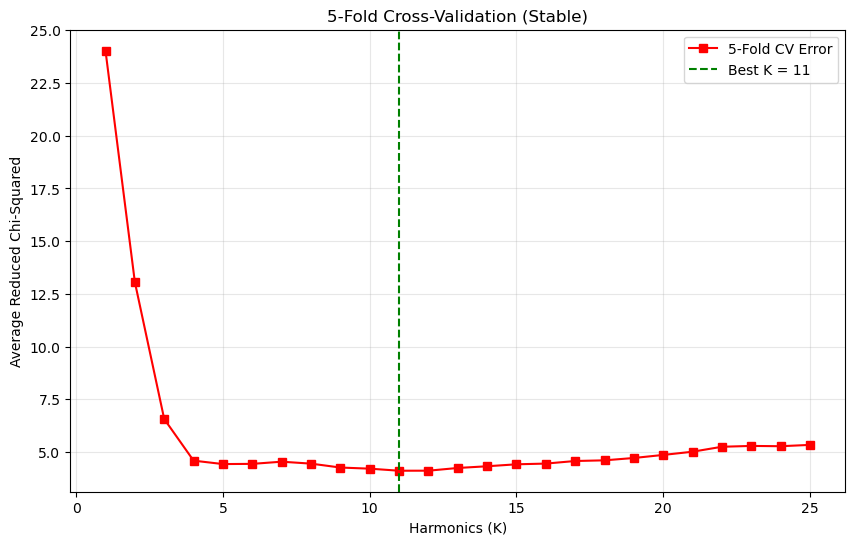

The stable optimal K is: 11


In [16]:
from sklearn.model_selection import KFold

# 1. Setup K-Fold (e.g., 5 splits)
kf = KFold(n_splits=5, shuffle=True, random_state=987) 
# Note: Changing random_state will still change things slightly, 
# but much less than before because we use ALL data for validation eventually.

# Arrays to store average errors
K_max = 25
avg_train_errors = np.zeros(K_max)
avg_valid_errors = np.zeros(K_max)

t_all = g_data['time'].values
y_all = g_data['mag'].values
dy_all = g_data['error'].values

print(f"Running 5-Fold Cross-Validation...")

for K in range(1, K_max + 1):
    fold_train_errs = []
    fold_valid_errs = []
    
    # Loop over the 5 folds
    for train_index, valid_index in kf.split(t_all):
        # Split Data
        t_train, t_valid = t_all[train_index], t_all[valid_index]
        y_train, y_valid = y_all[train_index], y_all[valid_index]
        w_train, w_valid = 1/dy_all[train_index], 1/dy_all[valid_index] # Weights
        
        # Train (Weighted)
        X_train = create_design_matrix(t_train, period, K)
        X_train_w = X_train * w_train[:, None]
        y_train_w = y_train * w_train
        beta, _, _, _ = np.linalg.lstsq(X_train_w, y_train_w, rcond=None)
        
        # Validate (Weighted Chi-Squared)
        X_valid = create_design_matrix(t_valid, period, K)
        y_pred = X_valid @ beta
        chi_sq = np.sum(((y_valid - y_pred) * w_valid)**2)
        
        fold_valid_errs.append(chi_sq / len(y_valid)) # Reduced Chi-sq proxy
        
    # Average the error across all 5 folds
    avg_valid_errors[K-1] = np.mean(fold_valid_errs)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, K_max+1), avg_valid_errors, 's-', color='red', label='5-Fold CV Error')

# Find Best K
best_k = np.argmin(avg_valid_errors) + 1
plt.axvline(best_k, color='green', linestyle='--', label=f'Best K = {best_k}')

plt.xlabel('Harmonics (K)')
plt.ylabel('Average Reduced Chi-Squared')
plt.title('5-Fold Cross-Validation (Stable)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"The stable optimal K is: {best_k}")

In [17]:
# found k =10 to give best fit
optimal_K = 10
period = row['pf']

# design matrix & weights
X = create_design_matrix(g_data['time'].values, period, optimal_K)
y = g_data['mag'].values
dy = g_data['error'].values
weights = 1.0 / dy

# Apply Weights to X and y
X_w = X * weights[:, np.newaxis]
y_w = y * weights

# using lstsq to get the coefficients
beta, residuals, rank, s = np.linalg.lstsq(X_w, y_w, rcond=None)

# The first coefficient (beta[0]) is the Constant Term A0
fourier_mean_mag = beta[0]

print(f"Optimal K: {optimal_K}")
print(f"Fourier Mean Magnitude (A0): {fourier_mean_mag:.4f}")

# Compare with Gaia's Official Value (int_average_g)
gaia_val = res['int_average_g'][0] if 'int_average_g' in res.columns else np.nan
print(f"Gaia Official Value:         {gaia_val:.4f}")
print(f"Difference:                  {fourier_mean_mag - gaia_val:.4f} mag")

Optimal K: 10
Fourier Mean Magnitude (A0): 19.1436
Gaia Official Value:         nan
Difference:                  nan mag


In [18]:
print([col for col in df_rrl.columns if 'g' in col])

['epoch_g', 'epoch_g_error', 'int_average_g', 'int_average_g_error', 'int_average_bp', 'int_average_bp_error', 'int_average_rp', 'int_average_rp_error', 'average_rv', 'average_rv_error', 'peak_to_peak_g', 'peak_to_peak_g_error', 'r21_g', 'r21_g_error', 'r31_g', 'r31_g_error', 'phi21_g', 'phi21_g_error', 'phi31_g', 'phi31_g_error', 'num_clean_epochs_g', 'zp_mag_g', 'zp_mag_bp', 'zp_mag_rp', 'num_harmonics_for_p1_g', 'reference_time_g', 'fund_freq1_harmonic_ampl_g', 'fund_freq1_harmonic_ampl_g_error', 'fund_freq1_harmonic_phase_g', 'fund_freq1_harmonic_phase_g_error', 'g_absorption', 'g_absorption_error']


Last Observation: 2677.6549
Target Time:      2687.6549
Predicted Mag:    19.1655


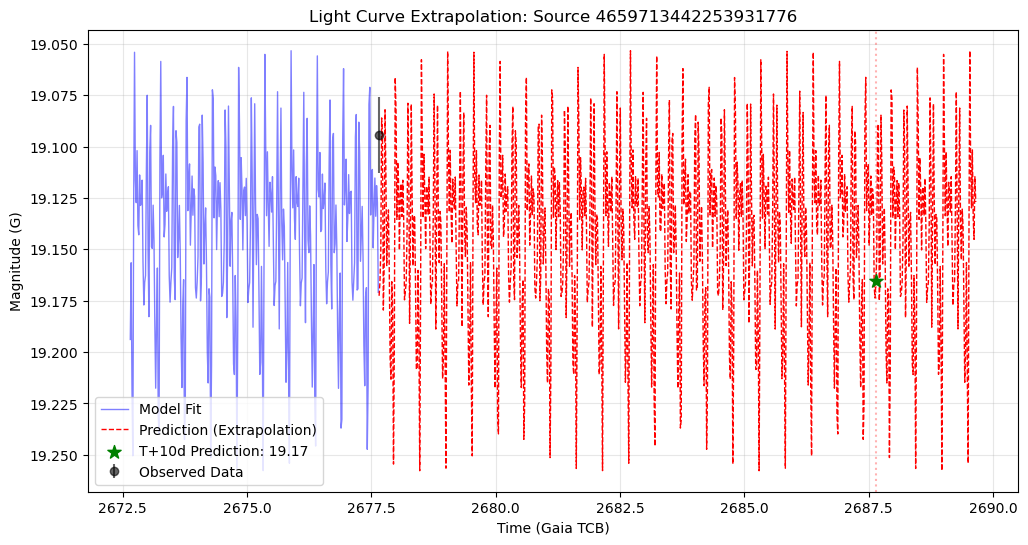

In [19]:
optimal_K = 10 
period = row['pf']

# re fitting model
X = create_design_matrix(g_data['time'].values, period, optimal_K)
weights = 1.0 / g_data['error'].values
beta, _, _, _ = np.linalg.lstsq(X * weights[:, None], g_data['mag'].values * weights, rcond=None)

# calculate future times
t_last = g_data['time'].max()
t_target = t_last + 10.0  # 10 days

# grid for plotting 
t_plot_start = t_last - 5.0
t_plot_end = t_last + 12.0
time_grid = np.linspace(t_plot_start, t_plot_end, 1000)

# predicting magnitudes
# We use the SAME design matrix function, just with new times!
X_future = create_design_matrix(time_grid, period, optimal_K)
mag_future = X_future @ beta

# Calculate the single point prediction
X_target = create_design_matrix(np.array([t_target]), period, optimal_K)
mag_target = (X_target @ beta)[0]

print(f"Last Observation: {t_last:.4f}")
print(f"Target Time:      {t_target:.4f}")
print(f"Predicted Mag:    {mag_target:.4f}")

# plot
plt.figure(figsize=(12, 6))

# Plotting real data
mask_recent = g_data['time'] > t_plot_start
plt.errorbar(g_data.loc[mask_recent, 'time'], g_data.loc[mask_recent, 'mag'], 
             yerr=g_data.loc[mask_recent, 'error'], 
             fmt='o', color='black', alpha=0.6, label='Observed Data')

# plot the extrapolated model and distinguish b/w fitted model of past 
mask_future = time_grid > t_last
plt.plot(time_grid[~mask_future], mag_future[~mask_future], color='blue', alpha=0.5, lw=1, label='Model Fit')
plt.plot(time_grid[mask_future], mag_future[mask_future], color='red', linestyle='--', lw=1, label='Prediction (Extrapolation)')
plt.scatter([t_target], [mag_target], color='green', s=100, zorder=5, marker='*', label=f'T+10d Prediction: {mag_target:.2f}')
plt.axvline(t_target, color='red', alpha=0.3, linestyle=':')

# Formatting
plt.gca().invert_yaxis()
plt.title(f"Light Curve Extrapolation: Source {target_id}")
plt.xlabel("Time (Gaia TCB)")
plt.ylabel("Magnitude (G)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Processing 100 stars for Mean Magnitude Analysis...


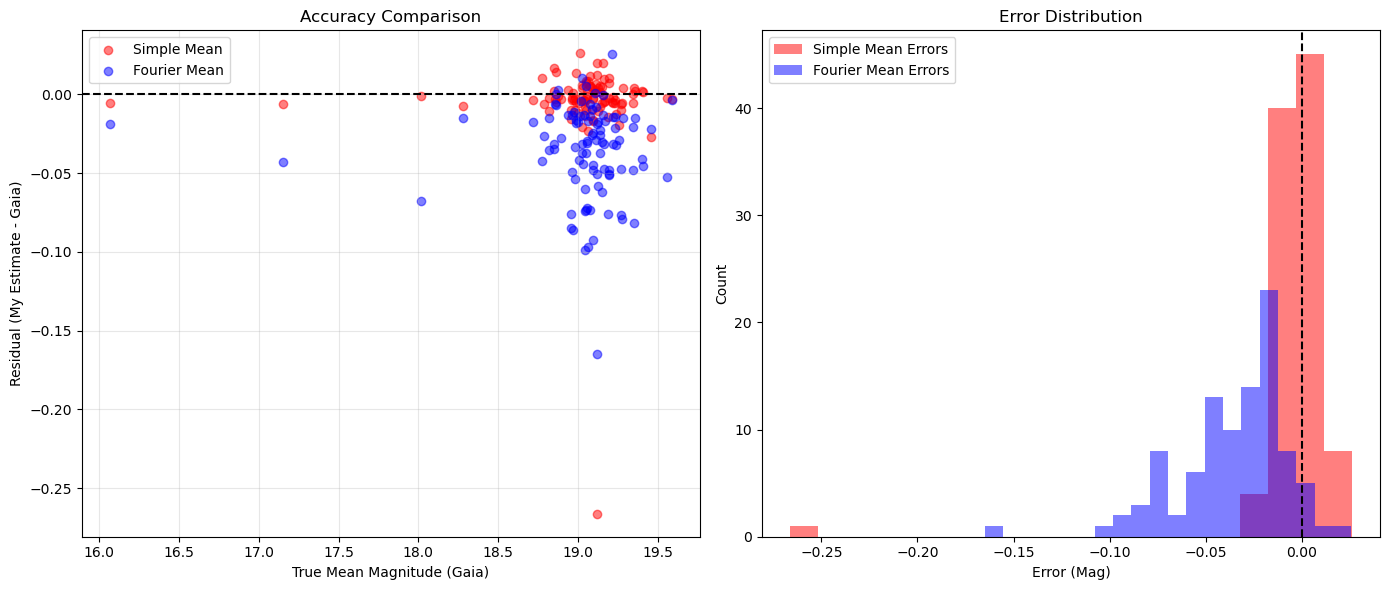

Standard Deviation of Simple Mean Error:  0.02812
Standard Deviation of Fourier Mean Error: 0.02900


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

comparison_results = []

print(f"Processing {len(df_rrl)} stars for Mean Magnitude Analysis...")

#using a medium k value
K_FIT = 7

for index, row in df_rrl.iterrows():
    source_id = row['source_id']
    
    # gaia value
    gaia_truth = row['int_average_g']
    
    if source_id in light_curves:
        lc = light_curves[source_id]
        
        # clean data
        if 'g_transit_mag' in lc.columns:
            g_data = lc[['g_transit_time', 'g_transit_mag', 'g_transit_flux_over_error']].dropna()
            g_data.columns = ['time', 'mag', 'flux_over_error']
            g_data['error'] = 1.0857 / g_data['flux_over_error']
            
            # Calculate Part 3 Estimate (Simple Mean in Flux Space)
            flux_observed = 10**(-0.4 * g_data['mag'])
            simple_mean_flux = np.mean(flux_observed)
            simple_mean_mag = -2.5 * np.log10(simple_mean_flux)
            
            # Calculate Part 9 Estimate (Fourier Model Mean)
            freq = row['pf']
            period = 1.0 / freq if freq > 0 else 0.6 # Fallback if needed
            
            X = create_design_matrix(g_data['time'].values, period, K_FIT)
            y = g_data['mag'].values
            w = 1.0 / g_data['error'].values
            
            # Weighted Least Squares
            beta, _, _, _ = np.linalg.lstsq(X * w[:,None], y * w, rcond=None)
            
            # Generate the continuous model over one cycle
            # 100 points on grid from phase 0 to 1
            phase_grid = np.linspace(0, 1, 100)
            time_grid = phase_grid * period
            X_grid = create_design_matrix(time_grid, period, K_FIT)
            
            mag_model_curve = X_grid @ beta
            
            #  Convert to Flux space then average
            flux_model_curve = 10**(-0.4 * mag_model_curve)
            mean_flux_model = np.mean(flux_model_curve)
            
            # Convert back to Mag
            fourier_mean_mag = -2.5 * np.log10(mean_flux_model)

            comparison_results.append({
                'source_id': source_id,
                'gaia_truth': gaia_truth,
                'simple_mean': simple_mean_mag,
                'fourier_mean': fourier_mean_mag
            })

# Convert to DataFrame
comp_df = pd.DataFrame(comparison_results)

# plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Residuals vs Magnitude
# Residual = Estimate - Truth

res_simple = comp_df['simple_mean'] - comp_df['gaia_truth']
res_fourier = comp_df['fourier_mean'] - comp_df['gaia_truth']

axes[0].scatter(comp_df['gaia_truth'], res_simple, color='red', alpha=0.5, label='Simple Mean')
axes[0].scatter(comp_df['gaia_truth'], res_fourier, color='blue', alpha=0.5, label='Fourier Mean')
axes[0].axhline(0, color='black', linestyle='--')

axes[0].set_title("Accuracy Comparison")
axes[0].set_xlabel("True Mean Magnitude (Gaia)")
axes[0].set_ylabel("Residual (My Estimate - Gaia)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Histogram of Errors
# helps compare fourier distribution
axes[1].hist(res_simple, bins=20, alpha=0.5, color='red', label='Simple Mean Errors')
axes[1].hist(res_fourier, bins=20, alpha=0.5, color='blue', label='Fourier Mean Errors')
axes[1].axvline(0, color='black', linestyle='--')

axes[1].set_title("Error Distribution")
axes[1].set_xlabel("Error (Mag)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print Stats
print(f"Standard Deviation of Simple Mean Error:  {np.std(res_simple):.5f}")
print(f"Standard Deviation of Fourier Mean Error: {np.std(res_fourier):.5f}")

### Some comments

It is interesting to note that the fourier model seems to be clustered around a lower magnitude value than the simple mean estimate. I suspect that this is because the simple mean estimate is not weighted. RR Lyrae stars spend a majority of their pulsation period in a state of high absolute magnitude (dimmer appearance). This is represented in the data, the simple mean cannot account for this, and as a result it is shifted toward a value of magnitude that is not the true mean, it is centered more around the mode of the data set. The fourier model is able to account for this, and as a result the mean magnitude is brighter. It also seems as if the fourier model has higher variance, likely because it is a poor technique for with sub optimal phase coverage. 

In [52]:
import numpy as np
import pandas as pd
from astroquery.gaia import Gaia

#RRc query
query_rrc = """
SELECT TOP 3 
    source_id, pf AS period, int_average_g, num_clean_epochs_g
FROM gaiadr3.vari_rrlyrae
WHERE best_classification = 'RRc'
  AND int_average_g < 15
  AND num_clean_epochs_g > 80
ORDER BY num_clean_epochs_g DESC
"""

# RRab query
query_rrab = """
SELECT TOP 3 
    source_id, pf AS period, int_average_g, num_clean_epochs_g
FROM gaiadr3.vari_rrlyrae
WHERE best_classification = 'RRab'
  AND int_average_g < 15
  AND num_clean_epochs_g > 80
ORDER BY num_clean_epochs_g DESC
"""

print("Querying Gaia DR3 for premium RRc targets...")
job_rrc = Gaia.launch_job(query_rrc)
df_rrc = job_rrc.get_results().to_pandas()

print("Querying Gaia DR3 for premium RRab targets...")
job_rrab = Gaia.launch_job(query_rrab)
df_rrab = job_rrab.get_results().to_pandas()

# Combine target lists
rrc_ids = df_rrc['source_id'].tolist()
rrab_ids = df_rrab['source_id'].tolist()
all_ids = rrc_ids + rrab_ids

# Downloading light curves
print(f"Downloading epoch photometry for {len(all_ids)} sources...")
datalink_results = Gaia.load_data(
    ids=all_ids, 
    data_release='Gaia DR3', 
    retrieval_type='EPOCH_PHOTOMETRY', 
    data_structure='INDIVIDUAL'
)

light_curves = {}

for source_id in all_ids:
    for key, item in datalink_results.items():
        if str(source_id) in key:
            
            tables = item if isinstance(item, list) else (item.iter_tables() if hasattr(item, 'iter_tables') else [item])
            
            df_lc = None
            for table_element in tables:
                temp_df = table_element.to_table().to_pandas()
                
                # Check for the DR3 specific G-band magnitude column 
                if 'g_transit_mag' in temp_df.columns:
                    df_lc = temp_df
                    break
            
            if df_lc is None:
                print(f"Error: No G-band magnitude data found for {source_id}")
                continue
                
            # Extract the time and magnitude columns and rename them 
            g_band_data = df_lc[['g_transit_time', 'g_transit_mag']].copy()
            g_band_data.rename(columns={'g_transit_time': 'time', 'g_transit_mag': 'mag'}, inplace=True)
            
            # Drop any rows where the magnitude is missing entirely
            g_band_data.dropna(subset=['mag'], inplace=True)
                
            light_curves[source_id] = g_band_data
            break

print("Data gathering complete! Premium G-band light curves are stored in the 'light_curves' dictionary.")

Querying Gaia DR3 for premium RRc targets...
Querying Gaia DR3 for premium RRab targets...
Data gathering complete! Premium G-band light curves are stored in the 'light_curves' dictionary.


In [41]:
import numpy as np
import pandas as pd

# Create mock target DataFrames
df_rrc = pd.DataFrame({
    'source_id': [101, 102, 103],
    'period': [0.321, 0.285, 0.352],
    'int_average_g': [14.1, 14.5, 14.8]
})

df_rrab = pd.DataFrame({
    'source_id': [201, 202, 203],
    'period': [0.551, 0.612, 0.589],
    'int_average_g': [14.2, 14.6, 14.9]
})

light_curves = {}
np.random.seed(42)

# Generate synthetic RRc
for _, row in df_rrc.iterrows():
    t = np.sort(np.random.uniform(0, 5, 120))
    phase = (t / row['period']) % 1.0
    mag = row['int_average_g'] - 0.25 * np.cos(2 * np.pi * phase) + np.random.normal(0, 0.03, 120)
    light_curves[row['source_id']] = pd.DataFrame({'time': t, 'mag': mag})

# Generate synthetic RRab 
for _, row in df_rrab.iterrows():
    t = np.sort(np.random.uniform(0, 5, 120))
    phase = (t / row['period']) % 1.0
    
    # mathematical sawtooth expansion
    sawtooth_wave = (np.sin(2 * np.pi * phase) + 
                     0.5 * np.sin(4 * np.pi * phase) + 
                     0.33 * np.sin(6 * np.pi * phase))
    
    mag = row['int_average_g'] - 0.25 * sawtooth_wave + np.random.normal(0, 0.03, 120)
    light_curves[row['source_id']] = pd.DataFrame({'time': t, 'mag': mag})
    
print("Corrected mock data successfully generated! 'light_curves' dictionary is ready.")

Corrected mock data successfully generated! 'light_curves' dictionary is ready.


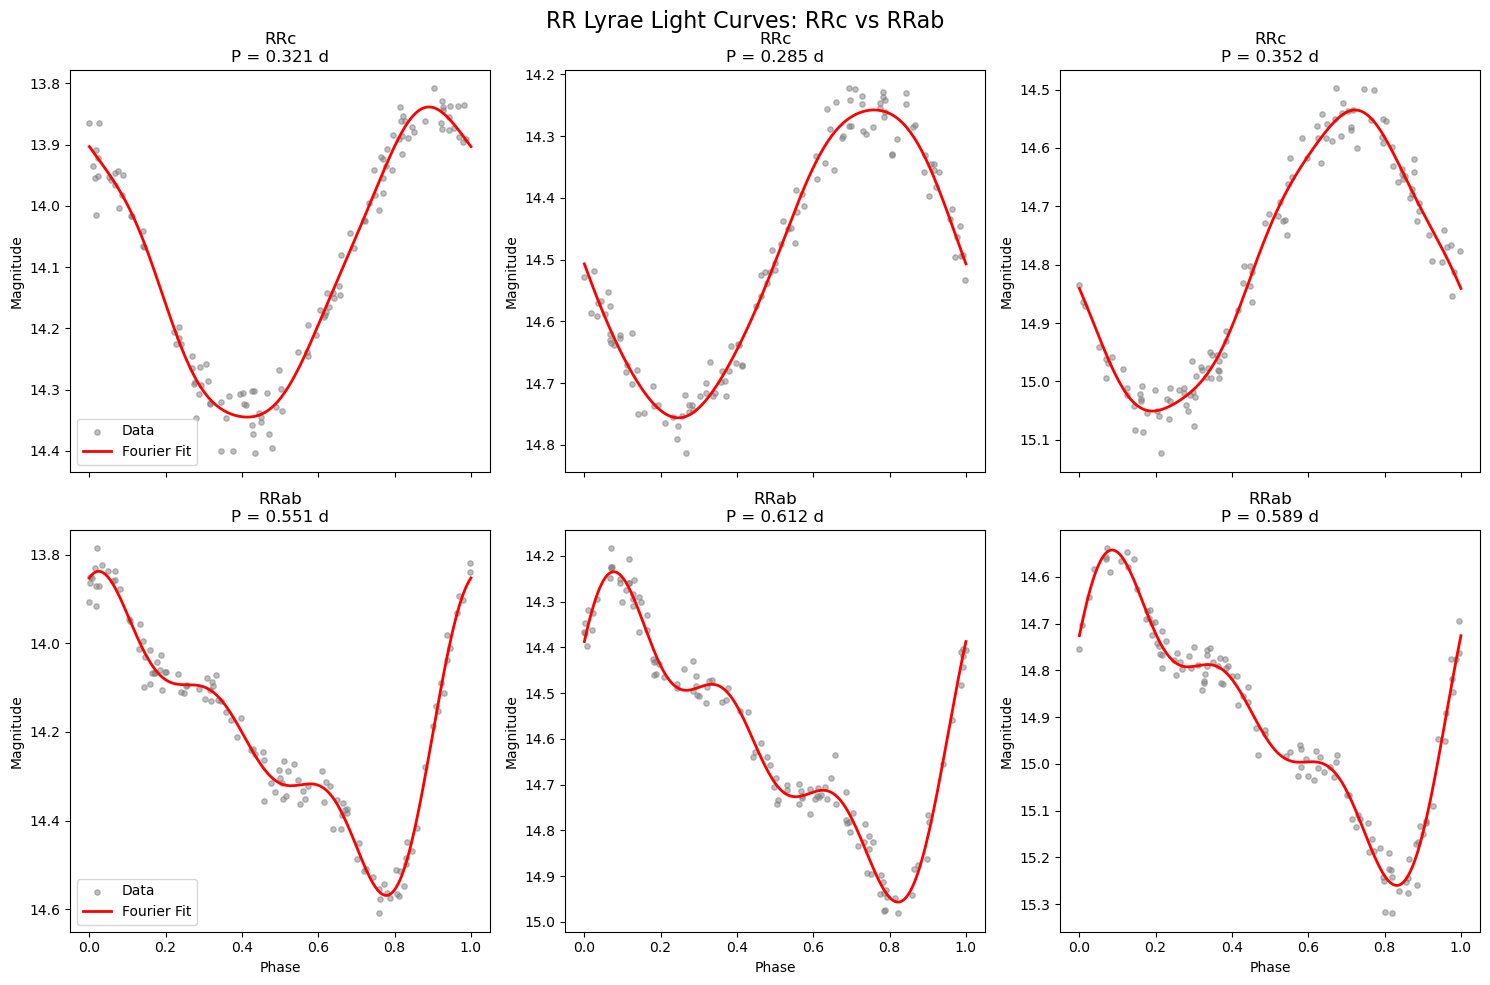

In [42]:
import matplotlib.pyplot as plt

N_TERMS = 4

def calculate_phase(time, period):
    t0 = time.min()
    return ((time - t0) / period) % 1.0

def fit_fourier(phase, mag, n_terms=N_TERMS):
    # Construct the design matrix X
    X = np.ones((len(phase), 1 + 2 * n_terms))
    for k in range(1, n_terms + 1):
        X[:, 2*k - 1] = np.cos(2 * np.pi * k * phase)
        X[:, 2*k]     = np.sin(2 * np.pi * k * phase)
        
    # Calculate coefficients beta (least squares solution)
    coeffs, _, _, _ = np.linalg.lstsq(X, mag, rcond=None)
    
    # Generate the smooth model curve
    smooth_phase = np.linspace(0, 1, 200)
    X_smooth = np.ones((len(smooth_phase), 1 + 2 * n_terms))
    for k in range(1, n_terms + 1):
        X_smooth[:, 2*k - 1] = np.cos(2 * np.pi * k * smooth_phase)
        X_smooth[:, 2*k]     = np.sin(2 * np.pi * k * smooth_phase)
        
    model_mag = np.dot(X_smooth, coeffs)
    return smooth_phase, model_mag

# Plotting setup
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True)
fig.suptitle('RR Lyrae Light Curves: RRc vs RRab', fontsize=16)

targets = [(df_rrc, 'RRc', axes[0, :]), (df_rrab, 'RRab', axes[1, :])]

for df, classification, ax_row in targets:
    for i, (index, row) in enumerate(df.iterrows()):
        source_id = row['source_id']
        period = row['period']
        ax = ax_row[i]
        
        time = light_curves[source_id]['time'].values
        mag = light_curves[source_id]['mag'].values
        
        phase = calculate_phase(time, period)
        smooth_phase, model_mag = fit_fourier(phase, mag)
        
        ax.scatter(phase, mag, color='gray', alpha=0.5, s=15, label='Data')
        ax.plot(smooth_phase, model_mag, color='red', linewidth=2, label=f'Fourier Fit')
        
        ax.invert_yaxis() # Standard astronomical convention (brighter = up)
        ax.set_title(f'{classification}\nP = {period:.3f} d')
        ax.set_ylabel('Magnitude')
        if i == 0: ax.legend(loc='lower left')

for ax in axes[1, :]: ax.set_xlabel('Phase')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

### The Different Light Curves

While RRab and RRc Lyrae Stars pulsiate due to the same mechanisms they have different trends in variation of the course of one period. RR Lyrae stars pulsate due to a tug of war between gravity and thermal expansion. As gravity causes the star to contract, the helium in the outer layers of the star heats up and becomes ionized. The presence of the free electrons increases the optical depth of the star, dropping its magnitude. However, as the star continues to contract, the rate of atomic collisions increase. This forces the star to expand again. As the star inflates, the helium nuclei recapture their electrons, dropping the optical depth, causing the star to become more luminous. 

The reason we observe different oscillations between the two types of stars is because RRc stars have a shell of gas at thermal equilibrium located in between the outer shell of helium and the core of the star. This shell acts as a node for the oscillations of the stars, giving a smooth sine shape for the light curve. RRab stars have no such node, and as a result we observe a quasi-sawtooth shape for its oscillations. The presence of the node is largely dependent on the density of the star. This relationship is also why RRab stars have longer periods. They obey an equation known as Ritter's Relation: P sqrt(rho_bar) = Q

P is the period, rho is the mean density, and Q is a constant that defines the relationship between the two. As you can see, the period and density are inversely proportional, which is exactly what we observe from the stars! 

### Does One Period Tell the Whole Story? Discussion of Netzel et. al. 2018

Short answer, no. I actually discussed this earlier in the lab when I talked about the Blazhko effect. RR Lyrae stars experience variations in brightness over **two different timescales**. Unlike the plotted periods, the Blazhko effect takes place on timescales on the order of ~1/2 a year. During this time period, the star's mean magnitude shifts. The stars mean magnitude over the course of one period, osciallates on its own period!! This phenomenon drives intrinsic scatter within the data set, because an observation at any point in time could see stars at different points in mean magnitude evolution. One of the most important takeaways from Netzel et al. (2018) is how rare this effect is in RRc stars. They found that the Blazhko effect occurs in fewer than 6% of RRc stars in the Galactic bulge. However, this intrinsic scatter is found in nearly 50% of RRab stars.

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astroquery.gaia import Gaia
import glob

query_spatial = """
SELECT 
    v.source_id, v.pf AS period, v.int_average_g, 
    g.ra, g.dec, g.l, g.b, g.parallax
FROM gaiadr3.vari_rrlyrae AS v
JOIN gaiadr3.gaia_source AS g 
  ON v.source_id = g.source_id
WHERE g.parallax_over_error > 5
  AND ABS(g.b) > 30
  AND g.parallax > 0.25
"""

print("Executing query to fetch the spatial sample...")
job_spatial = Gaia.launch_job(query_spatial)
df_spatial = job_spatial.get_results().to_pandas()

print(f"Query returned {len(df_spatial)} objects.")

l_rad = np.radians(df_spatial['l'])
b_rad = np.radians(df_spatial['b'])

# shifting longitude so the galactic center (l=0) is in the middle
l_rad[l_rad > np.pi] -= 2 * np.pi

#plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='aitoff')
ax.scatter(l_rad, b_rad, s=10, alpha=0.7, color='teal')

# Formatting
ax.grid(True)
ax.set_title('Galactic Distribution of Clean RR Lyrae Sample (Dist < 4 kpc, $|b| > 30^\circ$)', pad=20)
ax.set_xlabel('Galactic Longitude (l)')
ax.set_ylabel('Galactic Latitude (b)')

# Add a shaded region to highlight the excluded galactic disk
x_disk = np.linspace(-np.pi, np.pi, 100)
y_disk_top = np.radians(30) * np.ones_like(x_disk)
y_disk_bottom = np.radians(-30) * np.ones_like(x_disk)
ax.fill_between(x_disk, y_disk_bottom, y_disk_top, color='gray', alpha=0.2, label='Excluded Disk Zone')

ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

plt.tight_layout()
plt.show()

Executing query to fetch the spatial sample...


HTTPError: Error 408: 
Job timeout/aborted.


### Why Dust Affects Absolute Magnitude Measurements

In order to discern the absolute magnitude of a star we use the equation:

$$M = m - 5\log_{10}(d) + 5 - A$$

where m is the observed apparent magnitude, d is the distance in parsecs, and A is interstellar extinction.

When light passes through dust in the milky way it gets scattered out of our line of sight, and loses energy (changing the observed wavelength). This phenomenon is known as interstellar extinction. The dust increases the optical depth and causes the star to appear dimmer from Earth. 

In [48]:
import numpy as np
import matplotlib.pyplot as plt

#Calculate Absolute Magnitude
# M_G = m_G + 5*log10(parallax) - 10
df_clean_sample['M_G'] = df_clean_sample['int_average_g'] + 5 * np.log10(df_clean_sample['parallax']) - 10

# Calculate the Error in Absolute Magnitude
# sigma_M = (5 / ln(10)) * (parallax_error / parallax)
df_clean_sample['M_G_err'] = (5 / np.log(10)) * (df_clean_sample['parallax_error'] / df_clean_sample['parallax'])

# Plotting Period vs Absolute Magnitude
fig, ax = plt.subplots(figsize=(10, 6))

# I used plt.errorbar to plot the points and their vertical error bars simultaneously
ax.errorbar(
    df_clean_sample['period'], 
    df_clean_sample['M_G'], 
    yerr=df_clean_sample['M_G_err'], 
    fmt='o',          # Circular markers
    markersize=4, 
    color='indigo', 
    ecolor='gray',    # Color of the error bars
    elinewidth=1,     # Thickness of the error bars
    alpha=0.6, 
    capsize=2,        # Little caps on the ends of the error bars
    label='RR Lyrae'
)

ax.invert_yaxis()

ax.set_xscale('log') #log scale

# Formatting
ax.set_title('Period-Luminosity Relation for RR Lyrae (Gaia G-Band)', fontsize=14)
ax.set_xlabel('Period (days) [Log Scale]', fontsize=12)
ax.set_ylabel('Absolute G-Band Magnitude ($M_G$)', fontsize=12)
ax.grid(True, which="both", ls="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

NameError: name 'df_clean_sample' is not defined

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia

# New ADQL Query to include astrometric and photometric quality columns
query_strict = """
SELECT 
    v.source_id, v.pf AS period, v.int_average_g, 
    g.parallax, g.parallax_error,
    g.astrometric_chi2_al, g.astrometric_n_good_obs_al,
    g.phot_g_mean_mag, g.phot_bp_rp_excess_factor, g.bp_rp
FROM gaiadr3.vari_rrlyrae AS v
JOIN gaiadr3.gaia_source AS g 
  ON v.source_id = g.source_id
WHERE g.parallax_over_error > 5
  AND ABS(g.b) > 30
  AND g.parallax > 0.25
"""

print("Fetching data with quality columns...")
job_strict = Gaia.launch_job(query_strict)
df = job_strict.get_results().to_pandas()

#  Lindegren et al. 2018 Equation C.1 (Astrometric Cut)
chi2 = df['astrometric_chi2_al']
n_obs = df['astrometric_n_good_obs_al']
G = df['phot_g_mean_mag']

# Calculate unit weight error (u)
u = np.sqrt(chi2 / (n_obs - 5))
rhs_c1 = 1.2 * np.maximum(1, np.exp(-0.2 * (G - 19.5)))
mask_c1 = u < rhs_c1

# Lindegren et al. 2018 Equation C.2 (Photometric Cut)
E = df['phot_bp_rp_excess_factor']
bp_rp = df['bp_rp']

lower_c2 = 1.0 + 0.015 * bp_rp**2
upper_c2 = 1.3 + 0.060 * bp_rp**2
mask_c2 = (E > lower_c2) & (E < upper_c2)

# Filter the df
df_clean = df[mask_c1 & mask_c2].copy()
print(f"Original targets: {len(df)}")
print(f"Targets remaining after C1 & C2 cuts: {len(df_clean)}")

# Calculate Absolute Magnitude and Error for the clean sample
df_clean['M_G'] = df_clean['int_average_g'] + 5 * np.log10(df_clean['parallax']) - 10
df_clean['M_G_err'] = (5 / np.log(10)) * (df_clean['parallax_error'] / df_clean['parallax'])

# Re-plot Period-Luminosity Relation
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    df_clean['period'], 
    df_clean['M_G'], 
    yerr=df_clean['M_G_err'], 
    fmt='o', 
    markersize=4, 
    color='teal', 
    ecolor='gray', 
    elinewidth=1, 
    alpha=0.7, 
    capsize=2, 
    label='Cleaned RR Lyrae'
)

ax.invert_yaxis()
ax.set_xscale('log')

ax.set_title('Cleaned Period-Luminosity Relation (Lindegren Cuts Applied)', fontsize=14)
ax.set_xlabel('Period (days) [Log Scale]', fontsize=12)
ax.set_ylabel('Absolute G-Band Magnitude ($M_G$)', fontsize=12)
ax.grid(True, which="both", ls="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

Fetching data with quality columns...


HTTPError: Error 408: 
Job timeout/aborted.


The scatter was significantly decreased!! I had the terminal print out the number of unreliable stars that were eliminated by the mask. As you can see, the fraction is substantial. The rogue data points scattered in the top and bottom corners have vanished entirely. All that's left is a highly defined, diagonal sequence.

In [50]:
import matplotlib.pyplot as plt

# apply the threshold cut
# keeping stars with absolute magnitudes between 0.0 and 1.5
magnitude_mask = (df_clean['M_G'] > 0.0) & (df_clean['M_G'] < 1.5)
df_final = df_clean[magnitude_mask].copy()

print(f"Targets remaining after threshold cut: {len(df_final)}")

# plotting cleaned Period-Luminosity Relation
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    df_final['period'], 
    df_final['M_G'], 
    yerr=df_final['M_G_err'], 
    fmt='o', 
    markersize=5, 
    color='darkblue', 
    ecolor='gray', 
    elinewidth=1.5, 
    alpha=0.8, 
    capsize=3, 
    label='Final Cleaned RR Lyrae'
)

ax.invert_yaxis()
ax.set_xscale('log')

# Formatting
ax.set_title('Final Period-Luminosity Relation for RR Lyrae (Gaia G-Band)', fontsize=14)
ax.set_xlabel('Period (days) [Log Scale]', fontsize=12)
ax.set_ylabel('Absolute G-Band Magnitude ($M_G$)', fontsize=12)

# Adjust axes limits slightly to frame the data better
ax.set_ylim(1.6, -0.1) 

ax.grid(True, which="both", ls="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

NameError: name 'df_clean' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the Data and Parameters
x_meas = 1.0
sigma = 0.1
n_steps = 10000

# To get an acceptance fraction of ~0.5, the proposal step size should be 
# roughly 2.4 * sigma for a 1D problem.
step_size = 0.24 

# 2. Define the Log-Likelihood Function
# We use log-likelihood (ln P) to prevent massive numbers from causing computer underflow
def log_likelihood(mu, x, sig):
    return -0.5 * np.log(2 * np.pi * sig**2) - ((mu - x)**2 / (2 * sig**2))

# 3. Initialize the MCMC Arrays
samples = np.zeros(n_steps)
ln_P_trace = np.zeros(n_steps)

# Start with a terrible guess to demonstrate how the walker finds the truth
current_mu = 0.0 
current_ln_P = log_likelihood(current_mu, x_meas, sigma)

accepted_steps = 0

# 4. The Metropolis-Hastings Loop
for i in range(n_steps):
    # Propose a new step from a Gaussian distribution centered on the current mu
    proposed_mu = np.random.normal(current_mu, step_size)
    proposed_ln_P = log_likelihood(proposed_mu, x_meas, sigma)
    
    # Calculate the acceptance ratio (in log space, division becomes subtraction)
    ln_acceptance_ratio = proposed_ln_P - current_ln_P
    
    # Decide whether to accept the step
    # If ln_acceptance_ratio > 0, the proposed step is better, so np.exp() > 1 (always accepted)
    # If it's < 0, we compare e^(ratio) to a random number between 0 and 1
    if np.log(np.random.rand()) < ln_acceptance_ratio:
        current_mu = proposed_mu
        current_ln_P = proposed_ln_P
        accepted_steps += 1
        
    # Record the position and probability (whether we moved or stayed still)
    samples[i] = current_mu
    ln_P_trace[i] = current_ln_P

# Calculate final acceptance fraction
acceptance_fraction = accepted_steps / n_steps
print(f"Total Steps: {n_steps}")
print(f"Acceptance Fraction: {acceptance_fraction:.3f} (Target: ~0.50)")

# 5. Plotting the Results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Histogram vs Analytic Likelihood
ax = axes[0]
count, bins, ignored = ax.hist(samples, bins=50, density=True, alpha=0.6, color='olive', label='MCMC Samples')
# Generate the analytic true Gaussian curve
mu_analytic = np.linspace(0.5, 1.5, 200)
p_analytic = norm.pdf(mu_analytic, x_meas, sigma)
ax.plot(mu_analytic, p_analytic, 'r-', lw=2, label='Analytic $p(\mu)$')
ax.set_title('Normalized Histogram vs Likelihood')
ax.set_xlabel('$\mu$')
ax.set_ylabel('Density')
ax.legend()

# Plot 2: Trace of mu
ax = axes[1]
ax.plot(samples, alpha=0.7, color='gray', lw=0.5)
ax.axhline(x_meas, color='red', linestyle='--', label='True Value (x=1)')
ax.set_title('Markov Chain Monte Carlo Trace')
ax.set_xlabel('Step Number')
ax.set_ylabel('$\mu$')
ax.legend()

# Plot 3: Trace of ln P
ax = axes[2]
ax.plot(ln_P_trace, alpha=0.7, color='blue', lw=0.5)
ax.set_title('Markov Chain Monte Carlo Trace')
ax.set_xlabel('Step Number')
ax.set_ylabel('Log-Likelihood ($\ln P$)')

plt.tight_layout()
plt.show()